# 05 - Modelagem: Clustering de Setores Censitários

Pipeline:
1. UMAP  reduz as 11 features de proporção para 2D
2. HDBSCAN clusteriza os setores no espaço reduzido
3. Avaliação silhouette score, tamanho dos clusters
4. Visualização scatter plot geográfico colorido por cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

OUTPUT_DIR = Path('../outputs')

df = pd.read_parquet(OUTPUT_DIR / 'setores_features.parquet')

FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]

X = df[FEATURES].values
print(f'Setores: {len(df):,} | Features: {X.shape[1]}')

Setores: 30,355 | Features: 11


/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


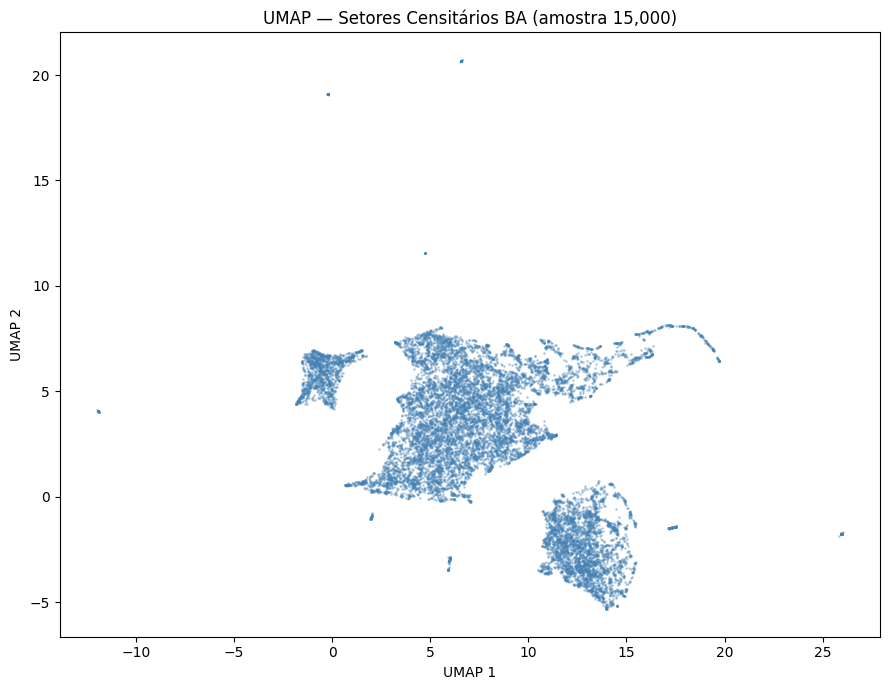

In [2]:
# UMAP — apenas visualização, amostra de 15k para não travar
UMAP_SAMPLE = 15_000
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(df), size=min(UMAP_SAMPLE, len(df)), replace=False)
idx_sample.sort()

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, n_epochs=200, random_state=42)
embedding_sample = reducer.fit_transform(X[idx_sample])

df['umap_x'] = np.nan
df['umap_y'] = np.nan
df.iloc[idx_sample, df.columns.get_loc('umap_x')] = embedding_sample[:, 0]
df.iloc[idx_sample, df.columns.get_loc('umap_y')] = embedding_sample[:, 1]

df_umap = df.iloc[idx_sample].copy()

plt.figure(figsize=(9, 7))
plt.scatter(df_umap['umap_x'], df_umap['umap_y'], s=1, alpha=0.3, c='steelblue')
plt.title(f'UMAP — Setores Censitários BA (amostra {UMAP_SAMPLE:,})')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/umap_setores.png', dpi=150)
plt.show()

In [3]:
# HDBSCAN sobre as features originais
# min_cluster_size escalado para 30k setores (~0.6% do total)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(X)
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters encontrados : {n_clusters}')
print(f'Ruído (-1)           : {n_noise:,} ({n_noise/len(df)*100:.1f}%)')
print()
print(df['cluster'].value_counts().sort_index())

Clusters encontrados : 7
Ruído (-1)           : 27,107 (89.3%)

cluster
-1    27107
 0      252
 1      722
 2      267
 3      956
 4      221
 5      429
 6      401
Name: count, dtype: int64


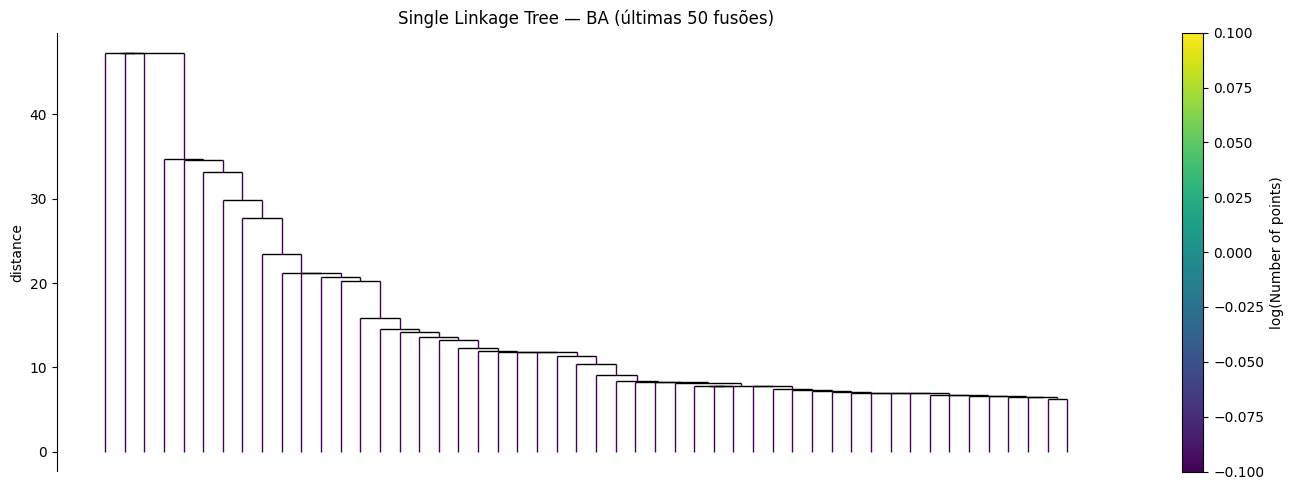

In [4]:
# Single Linkage Tree — vary_line_width=False evita RecursionError em datasets grandes
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree — BA (últimas 50 fusões)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/single_linkage_tree_ba.png', dpi=150)
plt.show()

In [5]:
# Silhouette score no espaço original das features
mask = df['cluster'] != -1
if mask.sum() > 1 and df.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score (BA): {score:.4f}')

Silhouette Score (BA): 0.3128


In [6]:
# Nomenclatura adaptativa por perfil dominante
NOMES_NRES = {
    'prop_estab_agropecuario':  'Rural / Agropecuário',
    'prop_estab_ensino':        'Educacional',
    'prop_estab_saude':         'Saúde',
    'prop_estab_outras':        'Comercial / Serviços',
    'prop_construcao':          'Em Construção',
    'prop_estab_religioso':     'Religioso',
    'prop_finalidade_comercial':'Comercial / Serviços',
    'prop_finalidade_mista':    'Uso Misto',
    'prop_domicilio_coletivo':  'Domicílio Coletivo',
}

perfil_z = df[df['cluster'] != -1].groupby('cluster')[FEATURES].mean()

def nomear(row):
    if row['prop_finalidade_mista'] > 0.5:
        return 'Uso Misto'
    if row['prop_domicilio_coletivo'] > 0.5:
        return 'Domicílio Coletivo'
    best_feat = max(NOMES_NRES, key=lambda f: row[f])
    best_z    = row[best_feat]
    dom_res   = row['prop_domicilio_particular']
    if best_z >= 0.2:
        prefixo = 'Residencial + ' if dom_res >= 0.2 else ''
        return f'{prefixo}{NOMES_NRES[best_feat]}'
    if dom_res >= 0.8:
        return 'Residencial Puro'
    if dom_res >= 0.4:
        return 'Residencial'
    return 'Residencial Típico'

# sem sufixo numérico — clusters com mesmo nome = mesmo tipo
nomes_finais = {cid: nomear(row) for cid, row in perfil_z.iterrows()}
df['cluster_nome'] = df['cluster'].map(lambda x: nomes_finais.get(x, 'Ruído') if x != -1 else 'Ruído')

print('Mapeamento de clusters (BA):')
tamanhos_nome = df[df['cluster'] != -1]['cluster_nome'].value_counts().sort_index()
for nome, n in tamanhos_nome.items():
    print(f'  {nome:<45} (n={n:,})')

Mapeamento de clusters (BA):
  Residencial Puro                              (n=2,274)
  Rural / Agropecuário                          (n=722)
  Uso Misto                                     (n=252)


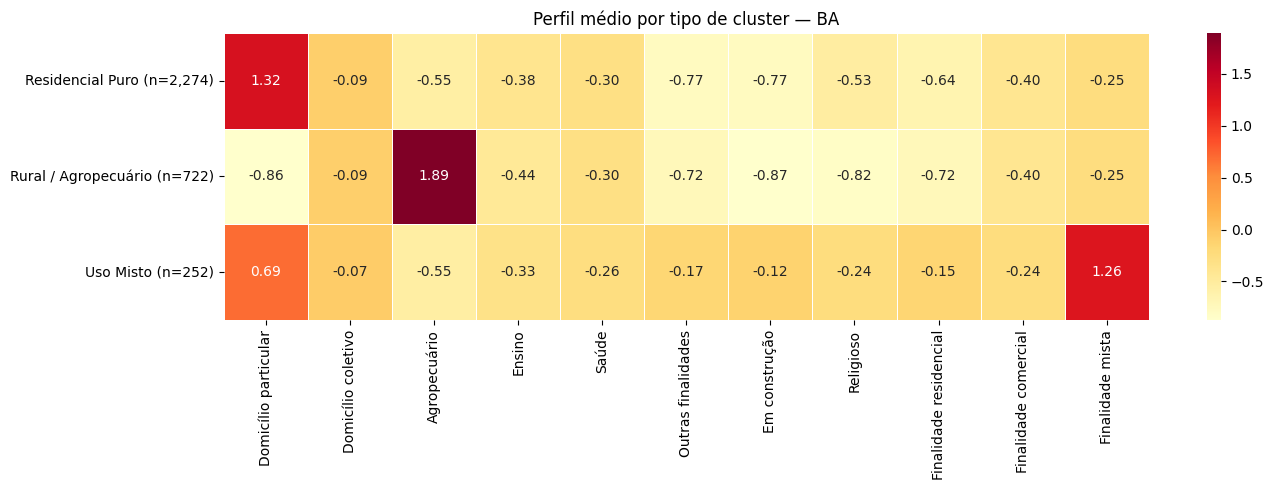

In [7]:
# Heatmap — agrega por cluster_nome (clusters do mesmo tipo são unidos)
FEATURES_LABEL = {
    'prop_domicilio_particular':  'Domicílio particular',
    'prop_domicilio_coletivo':    'Domicílio coletivo',
    'prop_estab_agropecuario':    'Agropecuário',
    'prop_estab_ensino':          'Ensino',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Outras finalidades',
    'prop_construcao':            'Em construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Finalidade residencial',
    'prop_finalidade_comercial':  'Finalidade comercial',
    'prop_finalidade_mista':      'Finalidade mista',
}

perfil = (df[df['cluster'] != -1]
          .groupby('cluster_nome')[FEATURES]
          .mean()
          .rename(columns=FEATURES_LABEL))

tamanhos_nome = df[df['cluster'] != -1]['cluster_nome'].value_counts()
perfil.index = [f"{nome} (n={tamanhos_nome[nome]:,})" for nome in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por tipo de cluster — BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/perfil_clusters_heatmap.png', dpi=150)
plt.show()

In [ ]:
# UMAP colorido por cluster com nomes
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b','#06d6a0','#ffd166']

df_umap = df.iloc[idx_sample].copy()
nomes_unicos = sorted(df_umap[df_umap['cluster'] != -1]['cluster_nome'].unique())
palette_nomes = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(nomes_unicos)}

fig, ax = plt.subplots(figsize=(11, 8))
noise_umap = df_umap[df_umap['cluster'] == -1]
ax.scatter(noise_umap['umap_x'], noise_umap['umap_y'], s=1, c='#cccccc', alpha=0.2, label='Ruído')

for nome in nomes_unicos:
    sub = df_umap[df_umap['cluster_nome'] == nome]
    ax.scatter(sub['umap_x'], sub['umap_y'], s=4, alpha=0.8,
               color=palette_nomes[nome], label=f'{nome} (n={len(sub):,})')

ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title(f'Clusters — UMAP + HDBSCAN BA (amostra {UMAP_SAMPLE:,})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/clusters_umap.png', dpi=150)
plt.show()

In [ ]:
# Mapa geográfico — todos os setores
noise = df[df['cluster'] == -1]
fig, ax = plt.subplots(figsize=(10, 12))
ax.scatter(noise['lon_centroide'], noise['lat_centroide'], s=0.3, c='#cccccc', alpha=0.1)

for nome in nomes_unicos:
    sub = df[df['cluster_nome'] == nome]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'], s=2, alpha=0.7,
               color=palette_nomes[nome], label=nome)

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Mapa de Setores — Clusters (BA)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/clusters_mapa_geo.png', dpi=150)
plt.show()

In [10]:
# Salvar resultado com cluster atribuído
df.to_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet', index=False)
print(f'Salvo: outputs/setores_clusterizados.parquet')

Salvo: outputs/setores_clusterizados.parquet
